In [1]:
%matplotlib widget

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.widgets import Button, Slider
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
import matplotlib.patches as patches
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.widgets import RectangleSelector

import cv2

from PIL import Image
from helpers.definitions import *
from helpers.plotting import *
from helpers.pose_construction import *
from helpers.json_handling import *
from helpers.camera import *

In [2]:
def make_ugly_corners(x_min, x_max, y_min, y_max):
    corners = (np.array([x_min, x_max, x_max, x_min]), np.array([y_min, y_min, y_max, y_max]))
    return corners

def interpolate_values(idx, bb):
    x_min_current = np.interp(idx, bb[:,0], bb[:,1])
    x_max_current = np.interp(idx, bb[:,0], bb[:,2])
    y_min_current = np.interp(idx, bb[:,0], bb[:,3])
    y_max_current = np.interp(idx, bb[:,0], bb[:,4])

    return x_min_current, x_max_current, y_min_current, y_max_current

In [10]:
resolution = (1920, 1080)

poses_path = 'pose_outputs'
npz_path = 'npz'
video_path = 'videos'
num_frames = 5400

# poses_2d, boxes_2d = read_keypoints_mmpose(poses_path, num_keypoints, num_frames, cam_names, suffix='_mmpose_body')
# poses_2d_masked = mask_keypoints(poses_2d, confidence_threshold=0.3, min_cameras=1)
video_dirs = []
for cam_name in cam_names:
    video_dirs.append(os.path.join(video_path, f'{cam_name}_selected_mmpose.mp4'))


In [11]:
# Specify the frame to be loaded
frame_idx = 0 # start frame
cam_name = "gopro1" # start camera
cam_idx = cam_names.index(cam_name)

# Load the given frame
video = cv2.VideoCapture(video_dirs[cam_idx])  # Replace with your image path
if not video.isOpened():
        raise FileNotFoundError(f"Cannot open video file: {video_dirs[0]}")

# Set the video to the nth frame
video.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

# Read the frame
success, frame = video.read()
if not success:
    raise ValueError(f"Frame {frame_idx} does not exist in the video.")
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

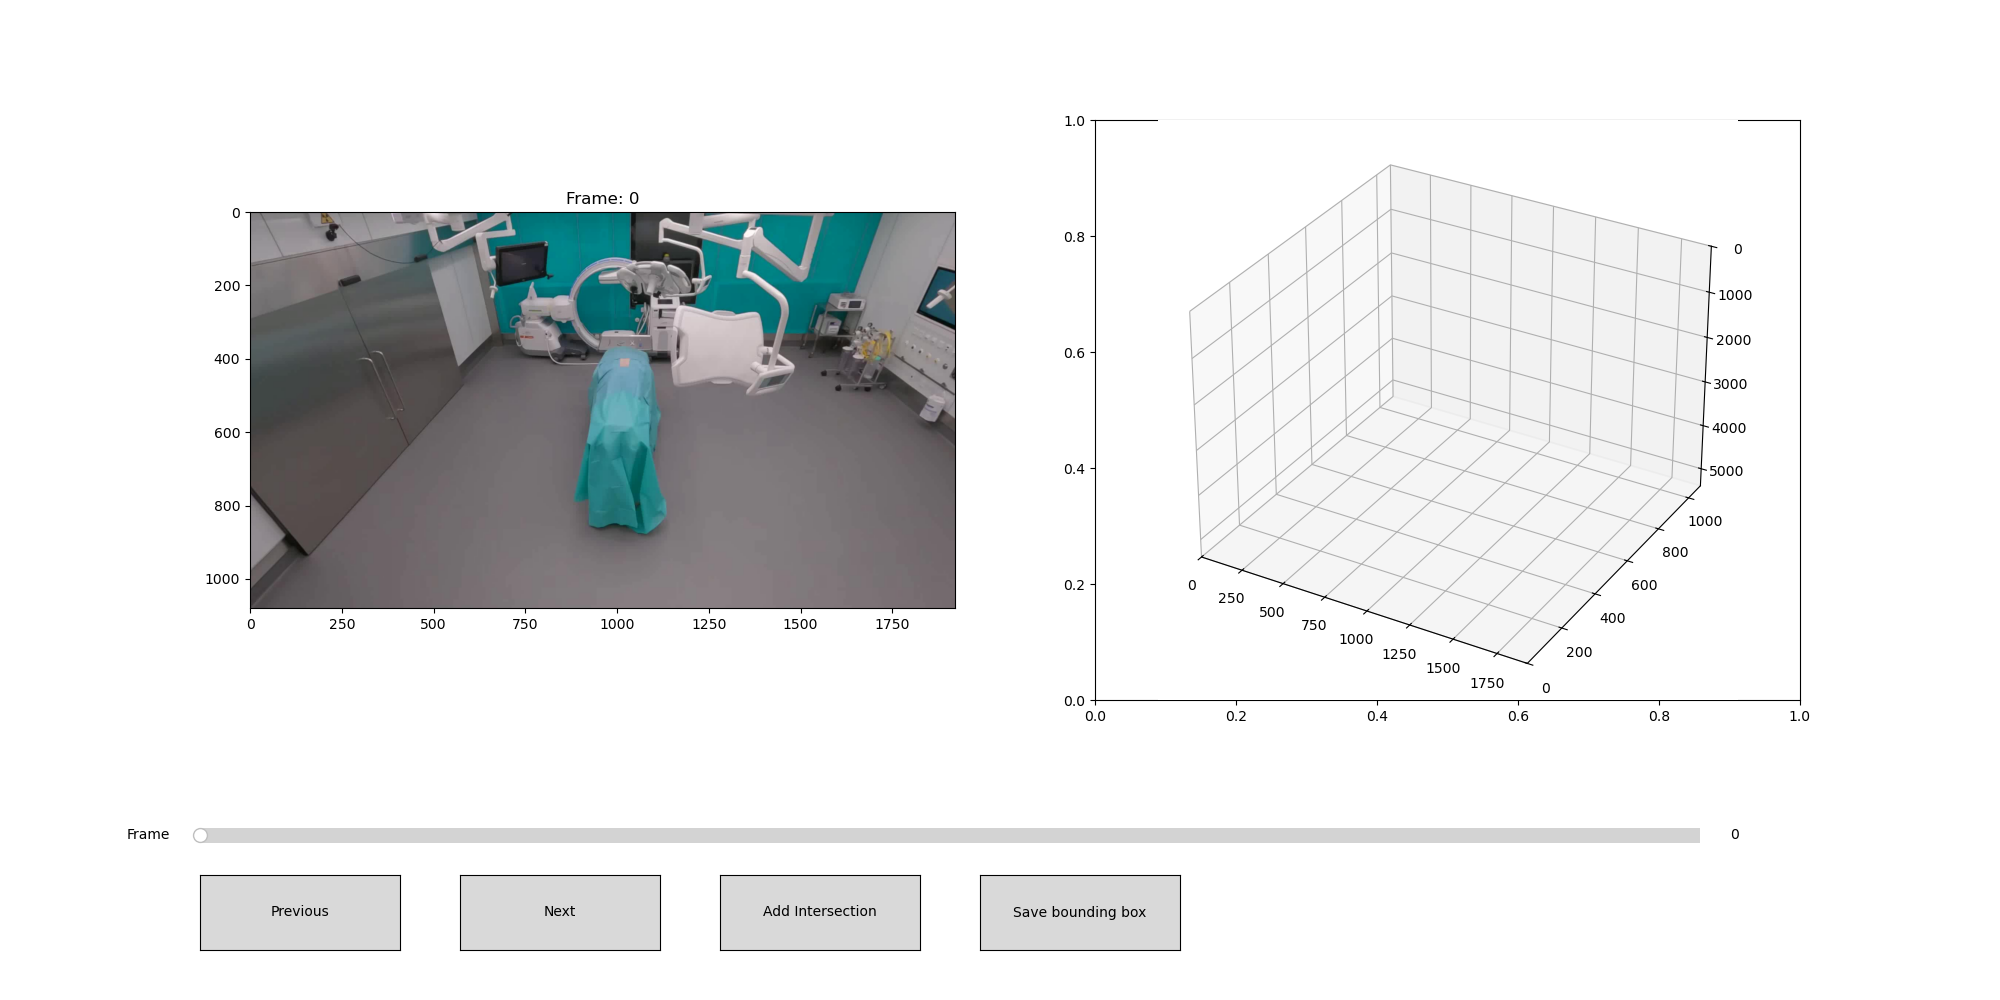

Rectangle selected from (1163.1, 872.0) to (1220.4, 929.2)
Rectangle selected from (1264.0, 806.6) to (1307.6, 858.3)
Rectangle selected from (1130.4, 490.4) to (1174.0, 539.5)
Rectangle selected from (1142.6, 513.6) to (1199.7, 569.2)
Rectangle selected from (1156.5, 513.6) to (1199.7, 556.8)
Rectangle selected from (1248.7, 551.9) to (1292.1, 598.2)
Rectangle selected from (1216.9, 517.9) to (1260.6, 563.5)
Rectangle selected from (1256.9, 548.4) to (1300.9, 595.7)
Rectangle selected from (1296.2, 629.5) to (1340.2, 677.7)
Rectangle selected from (1275.2, 562.6) to (1319.2, 610.1)
Rectangle selected from (1273.6, 564.9) to (1317.6, 612.5)
Rectangle selected from (1305.2, 655.5) to (1349.2, 703.8)
Rectangle selected from (1323.7, 680.1) to (1367.7, 728.8)
Rectangle selected from (1326.4, 732.1) to (1370.4, 781.8)
Rectangle selected from (1358.5, 738.9) to (1402.5, 788.7)
Rectangle selected from (1362.4, 741.1) to (1406.4, 791.7)
Rectangle selected from (1125.9, 913.0) to (1191.1, 959.

TypeError: Cannot interpret '4' as a data type

In [ ]:
frame_idx = 0
rectangle = None  # To store the draggable rectangle object
rect_ref = None
dragging_side = None  # To keep track of which side is being dragged
z_max = num_frames
z_min = 0
x1, y1 = (0, 0)
x2, y2 = (0, 0)
bone_counter = 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
plt.subplots_adjust(bottom=0.3)
ax2 = fig.add_subplot(122, projection='3d')

ax2.set_xlim(0, resolution[0])
ax2.set_ylim(0, resolution[1])
ax2.set_zlim(num_frames, 0)
img = ax1.imshow(frame, cmap='gray')

bb_dimensions = []
ax1.set_title(f"Frame: {frame_idx}")

# Callback function to capture rectangle coordinates
def onselect(eclick, erelease):
    global x1, y1, x2, y2
    x1, y1 = eclick.xdata, eclick.ydata
    x2, y2 = erelease.xdata, erelease.ydata
    print(f"Rectangle selected from ({x1:.1f}, {y1:.1f}) to ({x2:.1f}, {y2:.1f})")


def update_image(val):
    global rectangle, img, frame_idx, frame, video
    
    frame_idx = int(val)
    video.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

    # Read the frame
    success, frame = video.read()
    if not success:
        raise ValueError(f"Frame {frame_idx} does not exist in the video.")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    img.set_data(frame)
    ax1.set_title(f"Frame {val + 1}")

    bb_arr = np.array(bb_dimensions)
    
    if len(bb_dimensions) > 1 and frame_idx >= np.min(bb_arr[:,0]) and frame_idx <= np.max(bb_arr[:,0]):
        x_min_current = np.interp(val, bb_arr[:,0], bb_arr[:,1])
        x_max_current = np.interp(val, bb_arr[:,0], bb_arr[:,2])
        y_min_current = np.interp(val, bb_arr[:,0], bb_arr[:,3])
        y_max_current = np.interp(val, bb_arr[:,0], bb_arr[:,4])

        rectangle.extents = x_min_current, x_max_current, y_min_current, y_max_current
        rectangle.set_visible(True)
    elif len(bb_dimensions) > 0 and frame_idx in list(bb_arr[:,0]):
        rectangle.set_visible(True)
    else:
        rectangle.set_visible(False)


    plt.draw()

axslider = plt.axes([0.1, 0.15, 0.75, 0.03], facecolor='lightgoldenrodyellow')
slider = Slider(axslider, 'Frame', 0,num_frames  - 1, valinit=0, valstep=1)
slider.on_changed(update_image)


# Callback function for the 'Previous' button
def previous_image(event):
    global frame_idx, slider
    frame_idx = (frame_idx - 1) % num_frames  # Loop back to the last image if at the start
    update_image(frame_idx)
    slider.set_val(frame_idx)


# Callback function for the 'Next' button
def next_image(event):
    global frame_idx, slider
    frame_idx = (frame_idx + 1) % num_frames  # Loop back to the first image if at the end
    update_image(frame_idx)
    slider.set_val(frame_idx)

def add_intersection(event):
    global frame_idx, rectangle, bb_dimensions, x1, y1, x2, y2
    z_value = frame_idx
    x_min = np.min([np.int32(x1), np.int32(x2)])
    x_max = np.max([np.int32(x1), np.int32(x2)])
    y_min = np.min([np.int32(y1), np.int32(y2)])
    y_max = np.max([np.int32(y1), np.int32(y2)])

    intersect_values = np.array([z_value, x_min, x_max, y_min, y_max])

    bb_dimensions.append(intersect_values)

    # Sort bb_dimensions by the z_value (first element of each array)
    bb_dimensions = sorted(bb_dimensions, key=lambda x: x[0])

    # Plot all intersections in 3D
    ax2.cla()  # Clear the plot to avoid duplicating lines
    ax2.set_xlim(0, resolution[0])
    ax2.set_ylim(0, resolution[1])
    ax2.set_zlim(num_frames, 0)

    # Draw each intersection as a rectangle
    for i, rect in enumerate(bb_dimensions):
        z, x_min, x_max, y_min, y_max = rect

        corners = np.array([
            [x_min, y_min, z],
            [x_max, y_min, z],
            [x_max, y_max, z],
            [x_min, y_max, z],
            [x_min, y_min, z]  # Closing the loop
        ])

        ax2.plot3D(corners[:, 0], corners[:, 1], corners[:, 2], 'r-')

        # Connect edges between consecutive rectangles if more than one
        if i > 0:
            prev_rect = bb_dimensions[i - 1]
            prev_z, prev_x_min, prev_x_max, prev_y_min, prev_y_max = prev_rect

            # Define previous rectangle corners
            prev_corners = np.array([
                [prev_x_min, prev_y_min, prev_z],
                [prev_x_max, prev_y_min, prev_z],
                [prev_x_max, prev_y_max, prev_z],
                [prev_x_min, prev_y_max, prev_z]
            ])

            # Connect each corner in the current rectangle to the corresponding corner in the previous rectangle
            for j in range(4):
                ax2.plot3D(
                    [corners[j, 0], prev_corners[j, 0]],  # x coordinates
                    [corners[j, 1], prev_corners[j, 1]],  # y coordinates
                    [corners[j, 2], prev_corners[j, 2]],  # z coordinates
                    'r-'  # Red dashed line for connections
                )


def save_bounding_box(event):
    global bone_counter
    if len(bb_dimensions) > 1:
        bounding_box = np.zeros((num_frames, 4))

        bb_arr = np.array(bb_dimensions)
        
        z_min = np.int32(np.min(bb_arr[:, 0]))
        z_max = np.int32(np.max(bb_arr[:, 0]))

        for idx in range(z_min, z_max + 1):
            x_min, x_max, y_min, y_max = interpolate_values(idx, bb_arr)
            bounding_box[idx] = np.array([x_min, y_min, x_max, y_max])
        
        np.savez(os.path.join(npz_path, f'updated_{cam_name}_bbox.npz'), bbox=bounding_box)
        
        bone_counter += 1

        

    else:
        print('Too few intersections are added to create a bounding box!')




# Create 'Previous' button
ax_prev = plt.axes([0.1, 0.05, 0.1, 0.075])  # Position the 'Previous' button
btn_prev = Button(ax_prev, 'Previous')
btn_prev.on_clicked(previous_image)

# Create 'Next' button
ax_next = plt.axes([0.23, 0.05, 0.1, 0.075])  # Position the 'Next' button
btn_next = Button(ax_next, 'Next')
btn_next.on_clicked(next_image)

ax_intersect = plt.axes([0.36, 0.05, 0.1, 0.075])  # Position the 'Next' button
btn_intersect = Button(ax_intersect, 'Add Intersection')
btn_intersect.on_clicked(add_intersection)

save_bbs = plt.axes([0.49, 0.05, 0.1, 0.075])  # Position the 'Next' button
btn_save = Button(save_bbs, 'Save bounding box')
btn_save.on_clicked(save_bounding_box)


# Initialize the RectangleSelector
rectangle = RectangleSelector(ax1, onselect, useblit=True,
                                  button=[1],  # Only respond to left mouse button
                                  minspanx=5, minspany=5,  # Minimum size of the rectangle
                                  spancoords='pixels', interactive=True)
plt.show()

In [14]:
bounding_box = np.zeros((num_frames, 4))

bb_arr = np.array(bb_dimensions)

z_min = np.int32(np.min(bb_arr[:, 0]))
z_max = np.int32(np.max(bb_arr[:, 0]))

for idx in range(z_min, z_max + 1):
    x_min, x_max, y_min, y_max = interpolate_values(idx, bb_arr)
    bounding_box[idx] = np.array([x_min, y_min, x_max, y_max])

np.savez(os.path.join(npz_path, f'updated_{cam_name}_bbox.npz'), bbox=bounding_box)

bone_counter += 1
